# (02) MNIST: P-VAE test

project = ```VIB```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

See if ```<lin|lin>``` P-VAE works on MNIST.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_PoissonVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Trainer

In [6]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'lin|lin')
cfg_vae['n_latents'] = 2048
cfg_tr['epochs'] = 100

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'MNIST', 'n_ch': 32, 'n_latents': 2048, 'prior_clamp': -4, 'fit_prior': True, 'enc_type': 'lin', 
'dec_type': 'lin', 'enc_bias': False, 'dec_bias': False, 'init_dist': 'Normal', 'init_scale': 0.05}

Trainer:
{'lr': 0.002, 'epochs': 100, 'batch_size': 200, 'warm_restart': 2, 'optimizer_kws': {'weight_decay': 0.0003}, 
'grad_clip': 1000, 'kl_const_portion': 0.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  PoissonVAE |  3.2 Mil   |
|     ---     |    ---     |
|    fc_enc   |  1.6 Mil   |
|    fc_dec   |  1.6 Mil   |
+-------------+------------+

poisson_uniform_c(-4)_MNIST_z-2048_fp_nrm-none_<lin|lin>
mc_b200-ep100-lr(0.002)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(1000)_(2025_02_03,09:20)

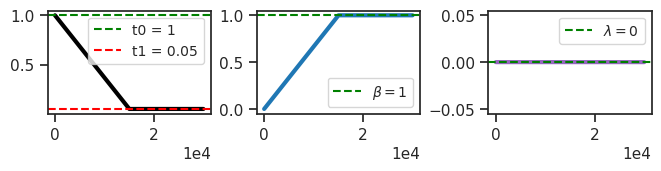

In [7]:
vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

vae.print()
print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.show_schedules()

In [8]:
print(tr.model)

PoissonVAE(
  (mse): MSELoss()
  (fc_enc): Linear(in_features=784, out_features=2048, bias=False)
  (fc_dec): Linear(in_features=2048, out_features=784, bias=False)
)

## Fit

In [9]:
tr.train()

epoch # 100, avg loss: 41.668072: 100%|███████| 100/100 [13:02<00:00,  7.83s/it]


In [10]:
x, g = next(iter(tr.dl_vld))
output = tr.model(x)

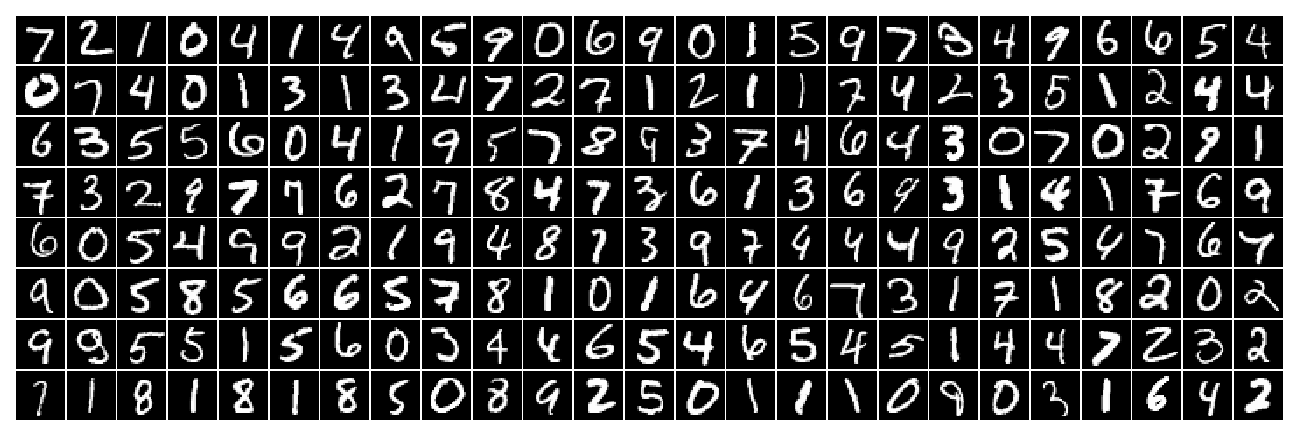

In [11]:
_ = plot_weights(x.squeeze(), method='none', nrows=8)

In [12]:
pred = output[-1]
pred.shape

torch.Size([200, 1, 28, 28])

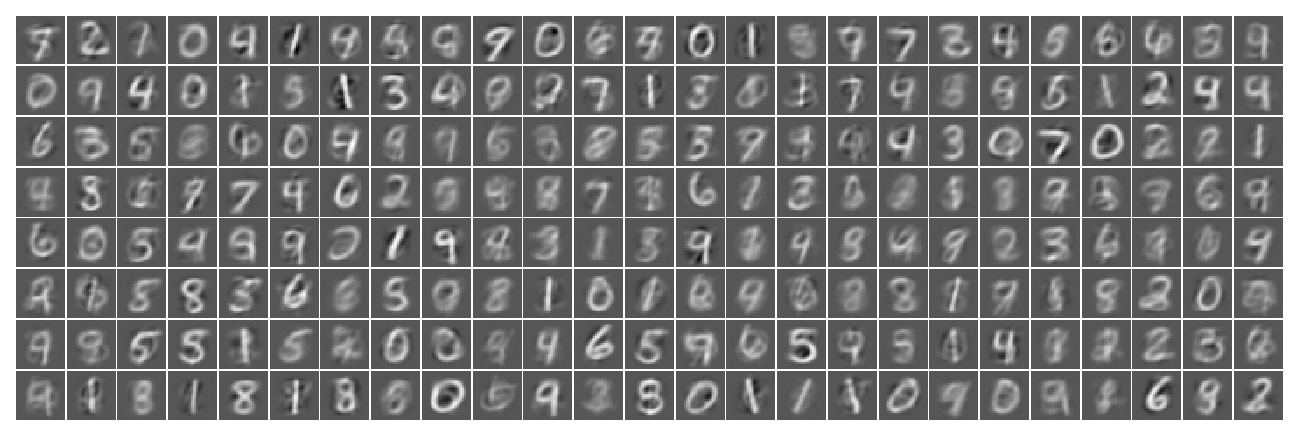

In [13]:
_ = plot_weights(pred.squeeze(), method='none', nrows=8)

In [14]:
data, loss, etc = tr.forward('vld')

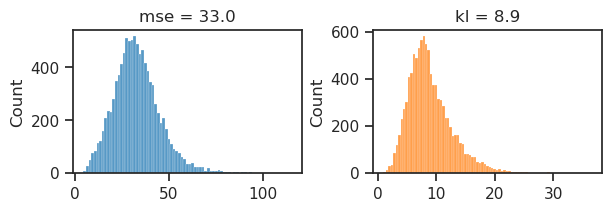

In [16]:
fig, axes = create_figure(1, 2)

sns.histplot(loss['mse'], ax=axes[0])
axes[0].set_title(f"mse = {loss['mse'].mean():0.1f}")

sns.histplot(loss['kl'], color='C1', ax=axes[1])
axes[1].set_title(f"kl = {loss['kl'].mean():0.1f}")

plt.show()

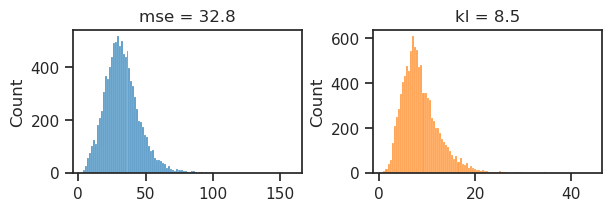